# Day 4 - Performance Analytics

## Objectives

- Daily Returns
- CAGR Calculation
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
import scipy
print(scipy.__version__)

1.17.1


In [4]:
nav = pd.read_csv(
    "../Data/Processed/clean_nav_history.csv"
)

performance = pd.read_csv(
    "../Data/Processed/clean_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../Data/Processed/clean_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    "../Data/Processed/clean_fund_master.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [5]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


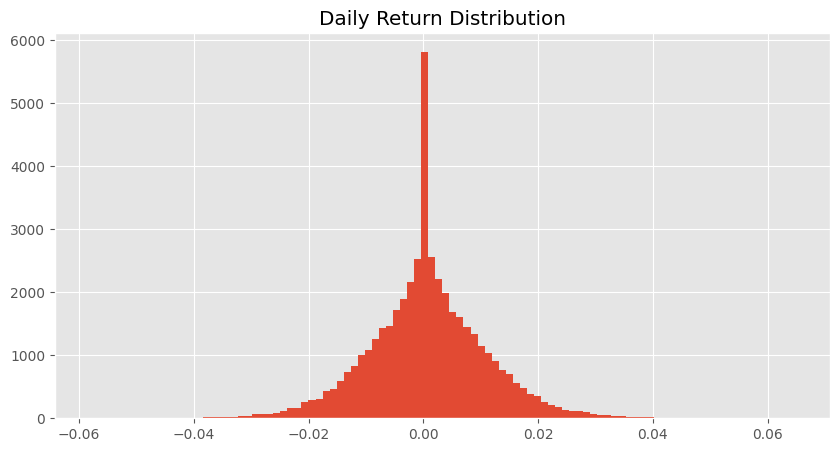

In [6]:
plt.figure(figsize=(10,5))

nav["daily_return"].hist(
    bins=100
)

plt.title("Daily Return Distribution")

plt.show()

In [7]:
cagr_list = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        (temp.iloc[-1]["date"] -
         temp.iloc[0]["date"]).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_list.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
RF = 0.065

sharpe_data = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    sharpe = (
        (returns.mean()*252 - RF)
        /
        (returns.std()*np.sqrt(252))
    )

    sharpe_data.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code","sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [9]:
sortino_data = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean()*252 - RF)
        /
        (downside.std()*np.sqrt(252))
    )

    sortino_data.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [10]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp[
        "drawdown"
    ].min()

    drawdown_list.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [11]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [12]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["index_value"]
    .pct_change()
)

nifty100.head()

KeyError: 'index_value'

In [13]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [14]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [16]:
nav.columns.tolist()


['amfi_code', 'date', 'nav', 'daily_return']

In [17]:
from scipy.stats import linregress

alpha_beta_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_list.append([
            code,
            intercept * 252,
            slope
        ])

alpha_beta = pd.DataFrame(
    alpha_beta_list,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [18]:
alpha_beta.to_csv(
    "../Data/Processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [19]:
scorecard = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard.head()


,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77


In [20]:
scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.006414,-0.043287


In [22]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"].rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"].rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"].rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"].rank(
        pct=True,
        ascending=False
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"].rank(
        pct=True,
        ascending=False
    )
)

In [23]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["dd_rank"] * 10

)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,1.000,0.675,1.000,0.5000,0.900,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,0.011455,-0.311719,0.875,0.700,0.975,0.3625,0.925,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.066265,-0.209609,0.650,0.750,0.800,0.6000,0.700,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.002523,-0.172481,0.800,0.875,0.825,0.0750,0.550,69.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,0.023684,-0.112657,0.600,1.000,0.850,0.4500,0.200,68.7500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,0.016232,-0.125883,0.525,0.775,0.700,0.7250,0.300,63.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,0.018134,-0.163967,0.450,0.950,0.925,0.1125,0.525,62.6875


In [24]:
scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,1.000,0.675,1.000,0.5000,0.900,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,0.011455,-0.311719,0.875,0.700,0.975,0.3625,0.925,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.066265,-0.209609,0.650,0.750,0.800,0.6000,0.700,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.002523,-0.172481,0.800,0.875,0.825,0.0750,0.550,69.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,0.023684,-0.112657,0.600,1.000,0.850,0.4500,0.200,68.7500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,0.016232,-0.125883,0.525,0.775,0.700,0.7250,0.300,63.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,0.018134,-0.163967,0.450,0.950,0.925,0.1125,0.525,62.6875


In [25]:
scorecard.to_csv(
    "../Data/Processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [26]:
len(scorecard)

40

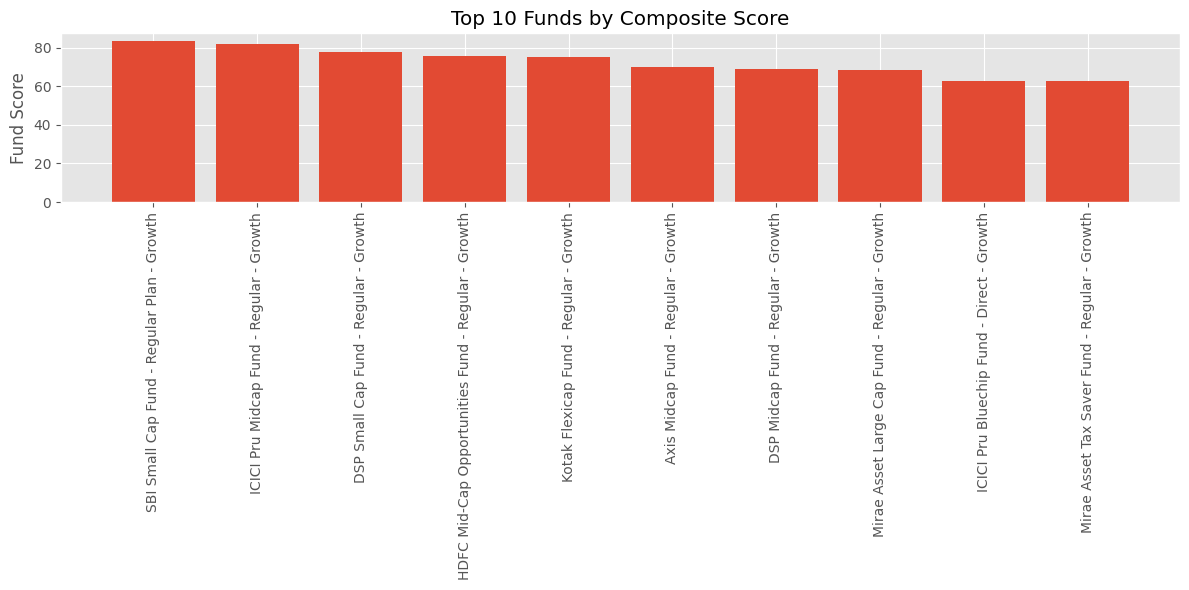

In [27]:
plt.figure(figsize=(12,6))

top10 = scorecard.head(10)

plt.bar(
    top10["scheme_name"],
    top10["fund_score"]
)

plt.xticks(rotation=90)
plt.ylabel("Fund Score")
plt.title("Top 10 Funds by Composite Score")

plt.tight_layout()

plt.savefig(
    "../reports/top10_fund_scorecard.png",
    bbox_inches="tight"
)

plt.show()

# Day 4 Performance Analytics Summary

## Metrics Computed

- Daily Returns for all 40 mutual fund schemes
- CAGR (1 Year, 3 Year, 5 Year)
- Sharpe Ratio using 6.5% risk-free rate
- Sortino Ratio using downside deviation
- Alpha and Beta against NIFTY100 benchmark
- Maximum Drawdown analysis
- Composite Fund Scorecard

## Key Findings

1. SBI Small Cap Fund achieved the highest composite score (83.38).
2. ICICI Prudential Midcap Fund ranked second with strong risk-adjusted returns.
3. Small-cap and mid-cap funds dominated the top rankings.
4. Several large-cap funds showed superior Sharpe Ratios despite lower raw returns.
5. Maximum drawdown significantly impacted final rankings.

## Deliverables Generated

- alpha_beta.csv
- fund_scorecard.csv
- top10_fund_scorecard.png
- Day4_Performance_Analytics.ipynb